<a href="https://colab.research.google.com/github/juanrmz85/everpeak-analysis/blob/main/practica_sprint_7_analisis_estadistico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Sprint 7.- Análisis estadístico para detectar patrones y outliers

En está lección aprendimos a usar un conjunto pequeño de funciones de pandas para hacer un diagnóstico rápido de calidad de datos.

Ahora vas a ejercitar las mismas herramientas que usamos para diagnosticar la calidad del dataset de EverPeak, pero ahora vistas desde un ángulo más técnico y práctico, como si estuvieras armando tu propio “kit básico” para revisar cualquier dataset real.

Todos estos comandos son sencillos, pero juntos permiten detectar problemas antes de limpiar y analizar.

### **1. Cargar el dataset y revisar estructura general.**

El primer paso siempre es entender qué columnas existen, qué tipo de datos contienen y cuántos valores no nulos trae cada una. Esto te ayuda a saber qué partes del dataset se pueden analizar de inmediato y cuáles necesitan más trabajo:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/tripleten_analisis_de_datos/everpeak_retail.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


### **2. Conteo de valores faltantes por columna**

**Objetivo:** Contar cuántos valores faltantes tiene cada variable de segmentación y ubicación, usando sumas, no porcentajes.

In [ ]:
payment_missing = df['payment_method'].isna().sum() #Calcular valores faltantes por columna
city_missing = df['city'].isna().sum()
state_missing = df['state'].isna().sum()

print("payment_method missing:", payment_missing)
print("city missing:", city_missing)
print("state missing:", state_missing)

payment_method missing: 0
city missing: 100
state missing: 100


### **3. Fechas sospechosas y montos extremos**

**Objetivo:** Medir cuántos registros tienen fechas sospechosas y montos anormalmente altos.

In [ ]:
df["order_date"] = pd.to_datetime(df['order_date'], errors='coerce') #Convertimos a fecha

invalid_year_2026_count = (df['order_date'].dt.year == 2026).sum() #Calculamos registros con 2026
missing_order_date_count = df['order_date'].isna().sum() #Calculamos registros Na

print("order_date año 2026:", invalid_year_2026_count)
print("order_date missing:", missing_order_date_count)

order_date año 2026: 15
order_date missing: 8


### **4. Cardinalidad en columnas de cliente**

**Objetivo:** Calcular la cardinalidad de columnas clave para entender si son IDs, categorías o variables poco útiles.

In [ ]:
customer_id_unicos = df['customer_id'].nunique() #Calculamos valores únicos
payment_unicos = df['payment_method'].nunique()
city_unicos = df['city'].unique()
state_unicos = df['state'].unique()

print("customer_id nunique:", customer_id_unicos)
print("payment_method nunique:", payment_unicos)
print("city nunique:", city_unicos)
print("state nunique:", state_unicos)

customer_id nunique: 1829
payment_method nunique: 4
city nunique: ['New York' 'Los Angeles' 'Chicago' 'Houston' 'Seattle' 'Boston' 'Denver'
 'Phoenix' 'Miami' 'San Francisco' nan]
state nunique: ['NY' 'CA' 'IL' 'TX' 'WA' 'MA' 'CO' 'AZ' 'FL' nan]


### **5. Detectar patrones de missingness por grupo**

**Objetivo:** Evaluar si el missing de city depende de alguna variable del negocio.

In [ ]:
missing_city_by_pay = df['city'].isna().groupby(df['payment_method']).mean().sort_values(ascending=False) #Calculamos % valores faltantes city por payment method.
print(missing_city_by_pay)

payment_method
credit_card    0.021517
debit_card     0.021300
cash           0.020101
paypal         0.015319
Name: city, dtype: float64


### **6. Comparar impacto entre drop e imputación.**

**Objetivo:** Medir cómo cambia la métrica cuando imputas o eliminas datos.

In [ ]:
before = df['order_value'].mean() # calculamos la media original aquí
df["order_value_imputed"] = df['order_value'].fillna(df['order_value'].median()) #Imputamos aquí
after = df['order_value'].mean() # calculamos la media después de imputar aquí

print(before)
print(after)

10071.564696485622
10071.564696485622


### **7. Comparamos indicadores estadísticos**

**Objetivo:** Comparar tres versiones de una columna numérica para decidir la estrategia final.

In [ ]:
before = df['customer_age'].mean() # Calculamos la media original

# Creamos "customer_age_med"
df["customer_age_med"] = df['customer_age'].fillna(df['customer_age'].median()) #Imputamos con mediana
after_med = df['customer_age_med'].mean() # calculamos la media aquí

# Creamos "customer_age_mean"
df["customer_age_mean"] = df['customer_age'].fillna(df['customer_age'].mean()) #Imputamos con media
after_mean = df['customer_age_mean'].mean() # calcula la media aquí

print(before)
print(after_med)
print(after_mean)

43.72869493618773
43.88658146964856
43.728694936187736


### **Análisis:**

De acuerdo con el resultado obtenido, podemos definir que la media y la mediana son similares, por lo que podemos definir que tenemos una distribución simetrica. En este sentido podemos entender que no existen valores extremos que distorsionen el valor promedio de la edad de los clientes.

### **8. Convertir a numérico múltiples columnas**

**Objetivo:** Aplicar una misma transformación a varias columnas usando una función + un bucle interno.

In [ ]:
# Creamos la función para convertir a numerico:
def convertir_columnas_numericas(df, columnas):
    for col in columnas:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

# Creamos la lista de columnas numéricas
columnas_numericas = ['price', 'quantity', 'order_value']

# Aplicamos la función convertir_columnas_numericas
df = convertir_columnas_numericas(df, columnas_numericas)

# Revisamos resultado
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             5008 non-null   int64         
 1   order_date           5000 non-null   datetime64[ns]
 2   customer_id          5008 non-null   int64         
 3   product_category     5008 non-null   object        
 4   price                5008 non-null   int64         
 5   quantity             5008 non-null   int64         
 6   order_value          5008 non-null   int64         
 7   payment_method       5008 non-null   object        
 8   city                 4908 non-null   object        
 9   state                4908 non-null   object        
 10  customer_age         4858 non-null   float64       
 11  order_value_imputed  5008 non-null   int64         
 12  customer_age_med     5008 non-null   float64       
 13  customer_age_mean    5008 non-nul

### **9. Extender la lista**

**Objetivo:** Para demostrar la escalabilidad del enfoque: agregamos una nueva columna y aplicamos la misma función sin reescribir código.

In [ ]:
# Agregamos la nueva columna
columnas_numericas.append('customer_id')

# Aplicamos nuevamente la función
df = convertir_columnas_numericas(df, columnas_numericas)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             5008 non-null   int64         
 1   order_date           5000 non-null   datetime64[ns]
 2   customer_id          5008 non-null   int64         
 3   product_category     5008 non-null   object        
 4   price                5008 non-null   int64         
 5   quantity             5008 non-null   int64         
 6   order_value          5008 non-null   int64         
 7   payment_method       5008 non-null   object        
 8   city                 4908 non-null   object        
 9   state                4908 non-null   object        
 10  customer_age         4858 non-null   float64       
 11  order_value_imputed  5008 non-null   int64         
 12  customer_age_med     5008 non-null   float64       
 13  customer_age_mean    5008 non-nul

### **10. Limpia múltiples columnas de texto con un loop**

**Objetivo:** Crear una función que limpie varias columnas categóricas al mismo tiempo usando:

 - Una lista de columnas
 - Un loop
 - La transformación .str.strip() para eliminar espacios innecesarios.

In [ ]:
print(df.head())

   order_id order_date  customer_id product_category  price  quantity  \
0         1 2024-02-02         2616           Sports    269        50   
1         2 2024-10-10         1736          Grocery     66         0   
2         3 2024-08-27         2543           Sports    267         0   
3         4 2024-06-09         2252             Toys    114       125   
4         5 2024-06-07         1583          Fashion    729        16   

   order_value payment_method         city state  customer_age  \
0        13385    credit_card     New York    NY          66.0   
1          660     debit_card  Los Angeles    CA          24.0   
2         5073    credit_card      Chicago    IL          23.0   
3        14290    credit_card     New York    NY          70.0   
4        11754    credit_card      Houston    TX          75.0   

   order_value_imputed  customer_age_med  customer_age_mean  
0                13385              66.0               66.0  
1                  660              24.0

In [ ]:
def step_strip_text(df):
    columnas = ['product_category', 'city', 'state']  # Definimos las columnas categóricas
    for col in columnas:   # Loop para aplicar strip() a cada columna
        df[col] = df[col].str.strip()
    return df

# Ejecutamos para probar
df = step_strip_text(df)
print(df.head())

   order_id order_date  customer_id product_category  price  quantity  \
0         1 2024-02-02         2616           Sports    269        50   
1         2 2024-10-10         1736          Grocery     66         0   
2         3 2024-08-27         2543           Sports    267         0   
3         4 2024-06-09         2252             Toys    114       125   
4         5 2024-06-07         1583          Fashion    729        16   

   order_value payment_method         city state  customer_age  \
0        13385    credit_card     New York    NY          66.0   
1          660     debit_card  Los Angeles    CA          24.0   
2         5073    credit_card      Chicago    IL          23.0   
3        14290    credit_card     New York    NY          70.0   
4        11754    credit_card      Houston    TX          75.0   

   order_value_imputed  customer_age_med  customer_age_mean  
0                13385              66.0               66.0  
1                  660              24.0

Del analisis anterior podemos identificar que existen valores de la columna quantity en 0, esto debe ser relacionado con algun error de captura. Antes de realizar la limpieza del resto de las columnas, haremos un tratamiento a estos datos para eliminar los 0's.

Del análisis de los datos del resto de las columnas, podemos identificar que tenemos la columna price, que corresponde al precio unitario del producto, y la columna order_value, es el total del valor de la venta. Por lo que en una relacion directa, podemos calcular la cantidad de producto vendido, haciendo una división de order_value entre price.

In [ ]:
# Calculamos la mediana de "quantity" antes de la modificación:
mediana_antes = df['quantity'].median()
print('Mediana de quantity antes de rellenar los 0´s:', {mediana_antes})

# Identificamos las filas donde "quantity" es 0:
ceros_quantity = (df['quantity'] == 0)

# Calculamos la nueva cantidad solo para esas filas, asegurandose de no dividir entre cero.
df.loc[ceros_quantity, 'quantity'] = df.loc[ceros_quantity].apply(
    lambda row: (row['order_value'] / row['price']) if row['price'] != 0 else 0, axis=1)

# Verificamos si quedo algún NaN por división entre cero
df['quantity'].fillna(0, inplace=True)

#Convertimos la columna "quantity" a tipo entero, por tratarse de valores enteros
df['quantity'] = df['quantity'].astype(int)

# Calculamos la mediana de "quantity" después de la modificación:
mediana_despues = df['quantity'].median()
print('Mediana de quantity después de rellenar los 0´s:', {mediana_despues})


Mediana de quantity antes de rellenar los 0´s: {0.0}
Mediana de quantity después de rellenar los 0´s: {14.0}


/tmp/ipykernel_1223/21688609.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[10. 19.  6. ...  7. 19.  4.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[ceros_quantity, 'quantity'] = df.loc[ceros_quantity].apply(
/tmp/ipykernel_1223/21688609.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['quantity'].fillna(0, inplace=True)


### **11. Crear Pipeline de limpieza**

**Objetivo:** Crear una función pipeline que orqueste todas las funciones de limpieza en el orden correcto:

 - Crear una función reemplace valores centinela por NaN, que pueda trabajar con múltiples columnas numéricas usando un bucle.
 - Crear una función que convierta columnas a tipo numérico y rellene valores ausentes con el promedio.

In [ ]:
# Creamos funciones
def reemplazar_sentinels(df, sentinels, numeric_cols):
    for col in numeric_cols:
        df[col] = df[col].replace(sentinels, pd.NA)
    return df

def rellenar_ausentes(df, cols_fill):
    for col in cols_fill:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col].fillna(df[col].mean(), inplace=True)
    return df

# Creamos función pipeline
def limpiar_df(df):
    valores_erroneos = [-999, 999, 0, 1] # Definimos valores_erroneos
    columnas_numericas = ['customer_age', 'price'] # Definimos columnas_numericas

    df = reemplazar_sentinels(df, valores_erroneos, columnas_numericas) # Aplicamos reemplazar_sentinels
    df = rellenar_ausentes(df, columnas_numericas) # Aplicamos rellenar_ausentes

    return df

# Observamos valores ausentes iniciales
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Aplicamos pipeline completo
df_clean = limpiar_df(df)
print("\nValores ausentes después del pipeline:")
print(df_clean[["customer_age", "price"]].isna().sum())
print()

Valores ausentes iniciales:
customer_age    150
price             0
dtype: int64

Valores ausentes después del pipeline:
customer_age    0
price           0
dtype: int64



/tmp/ipykernel_1223/2679902918.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             5008 non-null   int64         
 1   order_date           5000 non-null   datetime64[ns]
 2   customer_id          5008 non-null   int64         
 3   product_category     5008 non-null   object        
 4   price                5008 non-null   float64       
 5   quantity             5008 non-null   int64         
 6   order_value          5008 non-null   int64         
 7   payment_method       5008 non-null   object        
 8   city                 4908 non-null   object        
 9   state                4908 non-null   object        
 10  customer_age         5008 non-null   float64       
 11  order_value_imputed  5008 non-null   int64         
 12  customer_age_med     5008 non-null   float64       
 13  customer_age_mean    5008 non-nul

Guardamos el resultado en un nuevo documento para nuevas consultas.

In [ ]:
df_clean.to_csv("/content/drive/MyDrive/tripleten_analisis_de_datos/everpeak_retail_clean.csv", index=False)

### **12: Resumen numérico**

**Objetivo:** El equipo de Inteligencia Comercial necesita una visión rápida del desempeño de las categorías Fashion y Sports para entender su situación actual y detectar posibles anomalías en los datos.

In [ ]:
# Creamos dataframes para cada categoría
df_fashion = df_clean[df_clean['product_category'] == 'Fashion']
df_sports = df_clean[df_clean['product_category'] == 'Sports']

# Generamos el resumen de columnas numéricas con describe()
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']

print('Resumen estadístico de la categoría Fashion')
print(df_fashion[columnas_numericas].describe())

print()#Salto de Línea
print('Resumen estadístico de la categoría Sports')
print(df_sports[columnas_numericas].describe())

Resumen estadístico de la categoría Fashion
         order_value  customer_age         price    quantity
count     740.000000    740.000000    740.000000  740.000000
mean     8741.775676     48.034392    585.240663   21.644595
std     10312.376778     18.096992    655.100389   28.123003
min       122.000000     18.000000     25.000000    1.000000
25%      2916.000000     32.000000    274.750000    8.000000
50%      8077.500000     47.000000    457.000000   14.000000
75%     12526.500000     64.000000    679.000000   21.000000
max    224884.000000     80.000000  11836.000000  284.000000

Resumen estadístico de la categoría Sports
        order_value  customer_age        price    quantity
count    704.000000    704.000000   704.000000  704.000000
mean   10348.357955     49.689850   840.862216   18.857955
std     8815.365733     17.451683   848.098975   24.273272
min      195.000000     18.000000    47.000000    1.000000
25%     4301.500000     36.000000   347.000000    7.000000
50%    10

### **13. Promedio vs Mediana del gasto (Grocery)**

**Objetivo:** El equipo quiere entender si el gasto típico de los clientes que compran productos de supermercado está siendo afectado por outliers.

In [ ]:
# Filtramos la categoría Grocery
df_grocery = df_clean[df_clean['product_category'] == 'Grocery']

# Calculamos media y mediana del gasto
promedio = df_grocery['order_value'].mean()
mediana = df_grocery['order_value'].median()

# Imprimimos resultados
print("Promedio del gasto en Grocery:", f"{promedio:.2f}")
print("Mediana del gasto en Grocery:", f"{mediana:.2f}")

# Interpretación según comparación de media y mediana
print()
print('Existe una fuerte variación entre promedio y mediana, por lo que podriamos definir que existen valores extremos que influyen en el valor promedio del gasto')

Promedio del gasto en Grocery: 6943.14
Mediana del gasto en Grocery: 4131.00

Existe una fuerte variación entre promedio y mediana, por lo que podriamos definir que existen valores extremos que influyen en el valor promedio del gasto


### **14. Promedio vs Mediana**

**Objetivo:** El equipo sospecha que existen outliers en la cantidad de productos comprados.

In [ ]:
# Promedio y mediana de quantity
print("Promedio de quantity: ", df_clean['quantity'].mean())
print("Mediana de quantity: ", df_clean['quantity'].median())
print()
print("El promedio está afectado por los outliers o valores atípicos.")

Promedio de quantity:  28.074480830670925
Mediana de quantity:  14.0

El promedio está afectado por los outliers o valores atípicos.


### **15. Resumen numérico por ciudad**

**Objetivo:** El equipo necesita una visión rápida del comportamiento de los clientes en las ciudades New York y Los Angeles, para comprender su situación actual y detectar posibles anomalías en los datos.

In [ ]:
# Creamos dataframes para cada categoría
df_ny = df_clean[df_clean['city'] == 'New York']
df_la = df_clean[df_clean['city'] == 'Los Angeles']

# Resumen de columnas numéricas con describe()
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']

print('Resumen estadístico de la ciudad New York')
print(df_ny[columnas_numericas].describe())

print()
print('Resumen estadístico de la ciudad Los Angeles')
print(df_la[columnas_numericas].describe())

Resumen estadístico de la ciudad New York
         order_value  customer_age         price     quantity
count     497.000000    497.000000    497.000000   497.000000
mean    10545.410463     49.853490    741.454728    31.271630
std     13914.329615     17.507334   1105.570500    74.521867
min        58.000000     18.000000     12.000000     1.000000
25%      2862.000000     35.000000    203.000000     8.000000
50%     10682.000000     49.122491    457.000000    14.000000
75%     13327.000000     64.000000    787.000000    23.000000
max    224884.000000     80.000000  11836.000000  1258.000000

Resumen estadístico de la ciudad Los Angeles
         order_value  customer_age         price     quantity
count     511.000000    511.000000    511.000000   511.000000
mean    10456.168297     49.798596    750.332858    31.001957
std     15964.141858     17.694153   1174.680751    75.072605
min        44.000000     18.000000     13.000000     1.000000
25%      3164.000000     35.000000    204.00

### **16. Resumen categórico por ciudad**

**Objetivo:** El equipo necesita entender la distribución de los métodos de pago y las categorías de producto en Nueva York y Chicago para identificar patrones dominantes, diversidad de categorías y posibles anomalías.

In [ ]:
# Definimos columnas categóricas
columnas_categoricas = ['payment_method', 'product_category']

# Filtramos por ciudad
df_ny = df_clean[df_clean['city'] == 'New York']
df_chicago = df_clean[df_clean['city'] == 'Chicago']

# Resumen categórico New York
print("Resumen categórico - New York")
print(df_ny[['payment_method', 'product_category']].describe())

print()

# Resumen categórico Chicago
print("Resumen categórico - Chicago")
print(df_chicago[['payment_method', 'product_category']].describe())

Resumen categórico - New York
       payment_method product_category
count             497              497
unique              4                8
top       credit_card             Toys
freq              271               76

Resumen categórico - Chicago
       payment_method product_category
count             482              482
unique              4                8
top       credit_card             Toys
freq              284               74


### **17. Distribución completa de categorías con value_counts()**

**Objetivo:** Revisar todas las categorías de una columna junto con su frecuencia y calcular también los porcentajes.

In [ ]:
# Definimos columnas categóricas
columnas_categoricas = ['product_category', 'payment_method', 'city', 'state']

# Distribución completa de columnas categóricas usando for
for col in columnas_categoricas:
    print(col)
    print("Frecuencia absoluta")
    print(df_clean[col].value_counts())
    print()
    print("Frecuencia relativa")
    print(df_clean[col].value_counts(normalize=True))
    print()

product_category
Frecuencia absoluta
product_category
Fashion        740
Electronics    736
Beauty         721
Toys           719
Sports         704
Grocery        684
Home           679
?               25
Name: count, dtype: int64

Frecuencia relativa
product_category
Fashion        0.147764
Electronics    0.146965
Beauty         0.143970
Toys           0.143570
Sports         0.140575
Grocery        0.136581
Home           0.135583
?              0.004992
Name: proportion, dtype: float64

payment_method
Frecuencia absoluta
payment_method
credit_card    2742
paypal         1175
debit_card      892
cash            199
Name: count, dtype: int64

Frecuencia relativa
payment_method
credit_card    0.547524
paypal         0.234625
debit_card     0.178115
cash           0.039736
Name: proportion, dtype: float64

city
Frecuencia absoluta
city
Houston          514
Seattle          513
Los Angeles      511
New York         497
Miami            497
Phoenix          491
Chicago          482
Bosto

### **18. Resumen categórico (Toys)**

**Objetivo:** El equipo necesita entender la distribución de los métodos de pago y las ciudades asociadas a la categoría Toys, para identificar patrones dominantes, diversidad de ciudades y posibles anomalías.

In [ ]:
# Definimos columnas categóricas
columnas_categoricas = ['payment_method', 'city']

# Filtra por categoría
df_toys = df_clean[df_clean['product_category'] == 'Toys']

# Resumen categórico Toys
print("Resumen categórico - Toys")

print(df_clean[columnas_categoricas].value_counts())

Resumen categórico - Toys
payment_method  city         
credit_card     Los Angeles      294
                Chicago          284
                Houston          280
                New York         271
                Phoenix          269
                Seattle          268
                Boston           268
                Miami            258
                San Francisco    246
                Denver           245
paypal          Houston          126
                Seattle          126
                New York         124
                Miami            119
                San Francisco    118
                Los Angeles      115
                Phoenix          115
                Denver           110
                Chicago          105
debit_card      Seattle          103
paypal          Boston            99
debit_card      Miami             96
                Boston            94
                Phoenix           91
                San Francisco     87
                Hou

### **19. Distribución completa de ciudades con value_counts() (Sports)**

**Objetivo:** Revisar todas las ciudades asociadas a la categoría Sports, mostrando su frecuencia absoluta y su frecuencia relativa para entender la distribución de ubicaciones dentro de esta categoría.

In [ ]:
# Filtra por categoría
df_sports = df_clean[df_clean['product_category'] == 'Sports']

# Distribución de city
print("Frecuencia absoluta")
print(df_sports['city'].value_counts())
print("\nFrecuencia relativa")
print(df_sports['city'].value_counts(normalize=True))

Frecuencia absoluta
city
San Francisco    85
Los Angeles      84
Miami            75
New York         74
Denver           69
Seattle          67
Boston           66
Chicago          60
Houston          59
Phoenix          55
Name: count, dtype: int64

Frecuencia relativa
city
San Francisco    0.122478
Los Angeles      0.121037
Miami            0.108069
New York         0.106628
Denver           0.099424
Seattle          0.096542
Boston           0.095101
Chicago          0.086455
Houston          0.085014
Phoenix          0.079251
Name: proportion, dtype: float64


### **20. Analizando la distribución de precios**

**Objetivo:** El equipo de Inteligencia Comercial quiere entender cómo se distribuyen los precios y detectar posibles valores atípicos que puedan afectar los análisis.

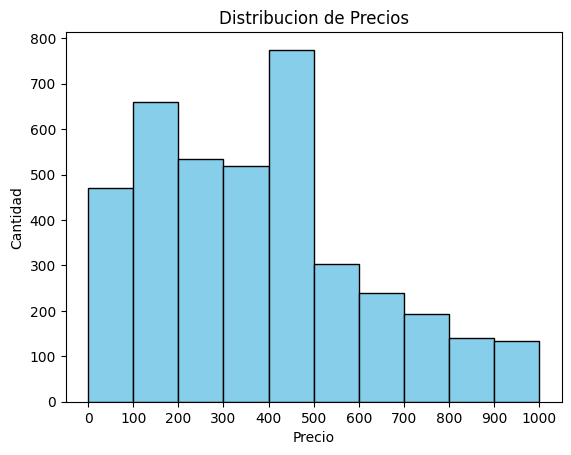

In [ ]:
# Graficamos histograma
counts, bin_edges, _ = plt.hist(df_clean['price'], range=(0, 1000), bins=10, color='skyblue', edgecolor='black')

plt.xticks(bin_edges) # Mostrar las marcas de los bins en el eje X
plt.xlabel('Precio')
plt.ylabel('Cantidad')
plt.title('Distribucion de Precios')
plt.show()

### **21. Distribución de edades de clientes**

**Objetivo:** El equipo quiere entender la distribución de las edades de los clientes (customer_age) para segmentar mejor las estrategias de marketing.

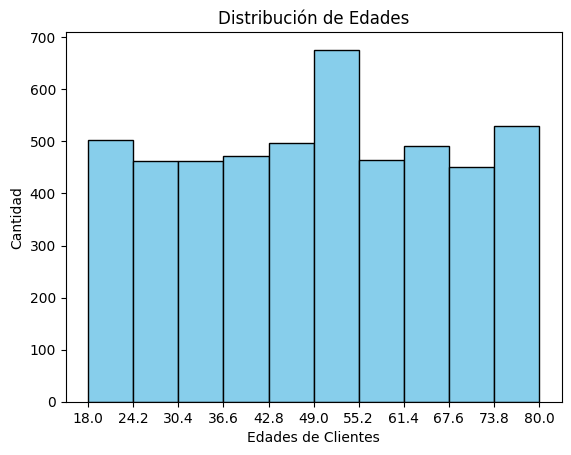

In [ ]:
# Graficamos histograma
counts, bin_edges, _ = plt.hist(df_clean['customer_age'], bins=10, color='skyblue', edgecolor='black')

plt.xticks(bin_edges)
plt.xlabel('Edades de Clientes')
plt.ylabel('Cantidad')
plt.title('Distribución de Edades')
plt.show()

### **22. Analizando la distribución de precios**

**Objetivo:** El equipo de Inteligencia Comercial quiere entender cómo se distribuyen los precios y detectar posibles valores atípicos que puedan afectar los análisis.

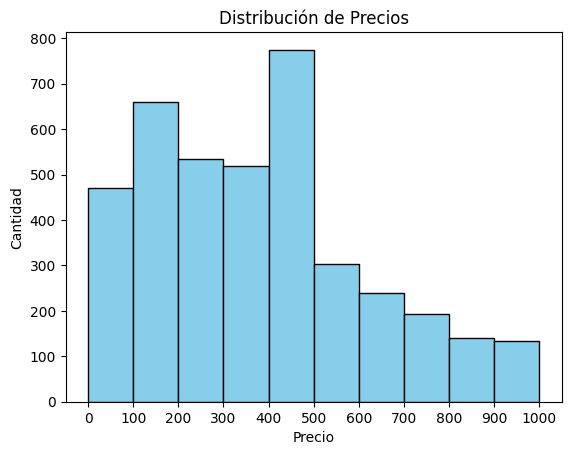

In [ ]:
# Graficamos histograma
counts, bin_edges, _ = plt.hist(df_clean['price'], bins=10, range=(0,1000), color='skyblue', edgecolor='black')

plt.xticks(bin_edges)
plt.xlabel('Precio')
plt.ylabel('Cantidad')
plt.title('Distribución de Precios')
plt.show()

### **23. Explorando la dispersión de cantidades con Boxplot**

**Objetivo:** El equipo de Inteligencia Comercial necesita analizar cómo se distribuyen las cantidades compradas (quantity) dentro de la categoría "Toys", para detectar valores extremos que podrían afectar decisiones de inventario y logística.

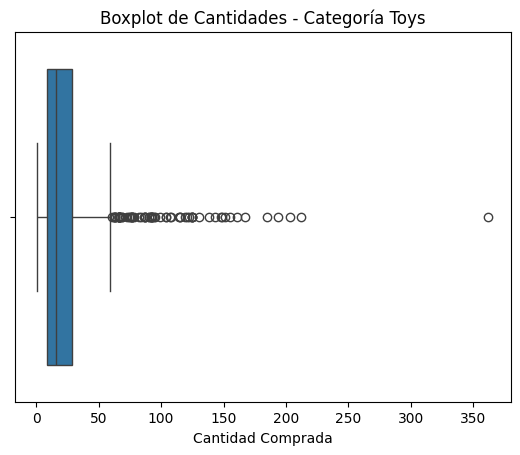

In [ ]:
df_toys = df_clean[df_clean['product_category'] == 'Toys']

# Graficamos BoxPlot
sns.boxplot(x=df_toys['quantity'])

plt.title('Boxplot de Cantidades - Categoría Toys')
plt.xlabel('Cantidad Comprada')
plt.show()

## **24. Boxplot del valor total de pedidos**

**Objetivo:** El equipo necesita analizar cuánto gastan los clientes en las categorías “Fashion” y “Sports”, evaluando la dispersión del order_value y detectando posibles outliers que puedan afectar decisiones de negocio.

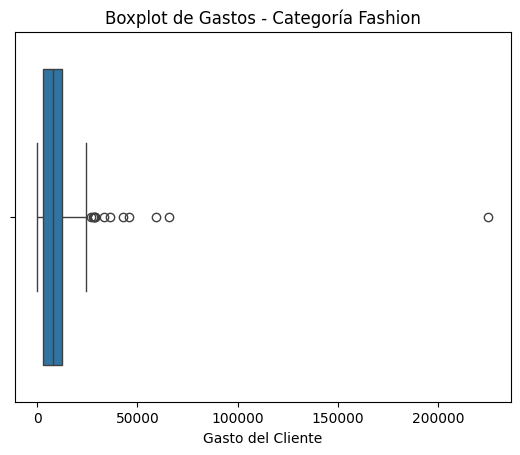

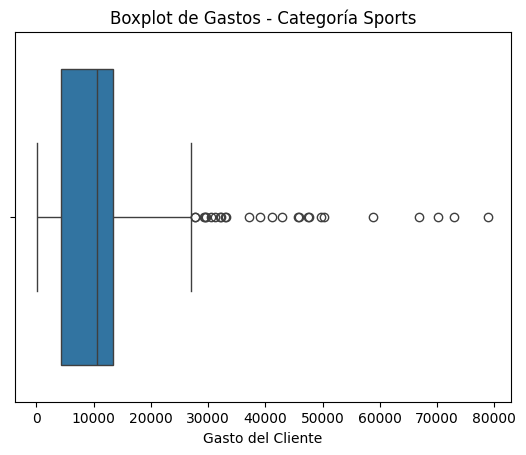

In [ ]:
# Filtramos datos
df_fashion = df_clean[df_clean['product_category'] == 'Fashion']
df_sports = df_clean[df_clean['product_category'] == 'Sports']

# BoxPlot Categoría Fashion
sns.boxplot(x=df_fashion['order_value'])
plt.xlabel('Gasto del Cliente')
plt.title('Boxplot de Gastos - Categoría Fashion')
plt.show()

# BoxPlot Categoría Sports
sns.boxplot(x=df_sports['order_value'])
plt.xlabel('Gasto del Cliente')
plt.title('Boxplot de Gastos - Categoría Sports')
plt.show()

### **25. Detectar outliers con IQR**

**Objetivo:** Identificar outliers en order_value con IQR.

In [ ]:
# Calculamos Q1, Q3 e IQR
Q1 = df_clean['order_value'].quantile(0.25)
Q3 = df_clean['order_value'].quantile(0.75)
IQR = Q3 - Q1

# Calculamos límite inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print('Primer cuartil: ', Q1)
print('Tercer cuartil: ', Q3)
print('IQR: ', IQR)

print("\nRegistros abajo del límite inferior")
print(df_clean[df_clean['order_value'] < limite_inferior])

print("\nRegistros arriba del límite superior")
print(df_clean[df_clean['order_value'] > limite_superior])

Primer cuartil:  3096.25
Tercer cuartil:  13159.25
IQR:  10063.0

Registros abajo del límite inferior
Empty DataFrame
Columns: [order_id, order_date, customer_id, product_category, price, quantity, order_value, payment_method, city, state, customer_age, order_value_imputed, customer_age_med, customer_age_mean]
Index: []

Registros arriba del límite superior
      order_id order_date  customer_id product_category   price  quantity  \
8            9 2024-03-14         2925           Beauty    55.0         1   
123        124 2024-06-21         1389      Electronics  1947.0        16   
155        156 2024-08-30         2901          Grocery    36.0         1   
199        200 2024-12-18         2919          Fashion  5174.0         7   
265        266 2024-07-31         1905      Electronics  2897.0        10   
...        ...        ...          ...              ...     ...       ...   
4934      4935 2024-05-19         1502      Electronics  4282.0        11   
4936      4937 2024-12-1

### **26. Z-scores**

**Objetivo:** Identificar outliers en order_value usando Z-Score.

In [ ]:
# Cálculo de la media
mean = df_clean['order_value'].mean()

# Cálculo de la desviación estándar
std = df_clean['order_value'].std()

# Creamos el z score
df_clean['z'] = (df_clean['order_value'] - mean) / std

# Cálculo de los valores extremos
print(df_clean[df_clean['z'] > 3])

      order_id order_date  customer_id product_category   price  quantity  \
293        294 2024-05-01         2149      Electronics  3336.0        17   
369        370 2024-10-09         2784      Electronics  5973.0        13   
375        376 2024-02-04         2285      Electronics  4782.0        20   
391        392 2024-03-06         2981      Electronics  2463.0        20   
397        398 2024-03-12         2024      Electronics  4893.0        18   
...        ...        ...          ...              ...     ...       ...   
4698      4699 2024-04-20         2059      Electronics  5227.0        11   
4732      4733 2024-10-06         2685           Sports  3394.0        14   
4908      4909 2024-10-19         1119      Electronics  3927.0        19   
4921      4922 2024-11-15         1621           Sports  2765.0        18   
4942      4943 2024-11-02         1979      Electronics  6478.0        11   

      order_value payment_method      city state  customer_age  \
293      

### **27. Comparar métodos en price**

**Objetivo:** Comparar métodos IQR y Z-Score en la columna price.

In [ ]:
# ----- IQR -----
# Calculamos Q1, Q3 e IQR
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1

# Calculamos límite inferior y superior
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# ----- Z-score -----
# calcular media, desviación estándar y z-score
mean = df_clean['price'].mean()
std = df_clean['price'].std()
df_clean['z'] = (df_clean['price'] - mean) / std

# ----- Mostrar resultados -----
print('Outliers usando IQR:')
print(df_clean[(df_clean['price'] < lower) | (df_clean['price'] > upper)])

print('\nOutliers usando Z-Score:')
print(df_clean[df_clean['z'] > 3])

Outliers usando IQR:
      order_id order_date  customer_id product_category   price  quantity  \
64          65 2024-05-30         1651           Sports  2106.0         5   
67          68 2024-05-15         2385             Home  5181.0         4   
95          96 2024-04-15         2991           Sports  1940.0         4   
123        124 2024-06-21         1389      Electronics  1947.0        16   
138        139 2024-05-07         2274      Electronics  2437.0         6   
...        ...        ...          ...              ...     ...       ...   
4974      4975 2024-10-20         2627      Electronics  1985.0         6   
4984      4985 2024-03-11         2509           Sports  1911.0         4   
4990      4991 2024-08-25         2569           Sports  2856.0         5   
4997      4998 2024-10-26         2838      Electronics  2699.0         4   
5007      5008        NaT         2509           Sports  1911.0         4   

      order_value payment_method         city state  c

### **28. Escribir tu primer IF-ELSE**

**Objetivo:** La gerencia de marketing nos ha pedido crear una regla que indique si los clientes en general superan cierto volumen de compra.

In [ ]:
# Calcular promedio y mediana
cantidad_promedio = df_clean['quantity'].mean()
cantidad_mediana = df_clean['quantity'].median()
print("Promedio:", cantidad_promedio)
print("Mediana:",cantidad_mediana)
print()

# Segmentación con media o promedio
if cantidad_promedio > 22:
	print('En promedio: volumen alto')
else:
	print('En promedio: volumen bajo')

# Segmentación con mediana
if cantidad_mediana > 22:
    print('Según la mediana: volumen alto')
else:
    print('Según la mediana: volumen bajo')

Promedio: 28.074480830670925
Mediana: 14.0

En promedio: volumen alto
Según la mediana: volumen bajo


### **28. Mejorar tu primer IF-ELSE**

**Objetivo:** La gerencia de marketing nos ha pedido mejorar la regla anterior agregando una tercera categoría.

In [ ]:
# Calcular promedio y mediana
cantidad_promedio = df_clean['quantity'].mean()
cantidad_mediana = df_clean['quantity'].median()
print("Promedio:", cantidad_promedio)
print("Mediana:",cantidad_mediana)
print()

# Segmentación con media o promedio
if cantidad_promedio > 22:
	print("En promedio: volumen alto")
elif cantidad_promedio >= 10:
    print('En promedio: volumen medio')
else:
	print("En promedio: volumen bajo")

# Segmentación con mediana
if cantidad_mediana > 22:
	print("Según la mediana: volumen alto")
elif cantidad_mediana >= 10:
    print('Según la mediana: volumen medio')
else:
	print("Según la mediana: volumen bajo")

Promedio: 28.074480830670925
Mediana: 14.0

En promedio: volumen alto
Según la mediana: volumen medio


### **29. Segmentación básica con np.where()**

**Objetivo:** La gerencia de marketing nos ha pedido segmentar a los clientes por volumen de compra.

In [ ]:
# Crear columna nueva
df_clean["volume_segment"] = np.where(
    df_clean['quantity'] > 22, 'High Volume', 'Low Volume'
)

# Verificar cambios
print(df_clean['volume_segment'].value_counts())

volume_segment
Low Volume     3766
High Volume    1242
Name: count, dtype: int64


### **30. Segmentación avanzada con función y apply**

**Objetivo:** La gerencia de marketing nos ha pedido segmentar los clientes por edad y por volumen de compra, separando en 4 segmentos.

In [ ]:
def classify_volume(row):
    age = row['customer_age'] # extrae la edad
    qty = row['quantity'] # extrae la cantidad de compra

    # 1. Manejo de valores nulos/faltantes
    # pd.isna() verifica de forma robusta si el valor es NaN
    if pd.isna(age) or pd.isna(qty):
        return "Error en Datos"

    # --- 2. Segmentación de Altas Cantidades ---
    if qty > 22:
        if age > 55:
            return "Sr. High Volume"
        else: # age <= 55
            return "Jr. High Volume"

    # --- 3. Segmentación Bajas Cantidades ---
    elif qty <= 22:
        if age > 55:
            return "Sr. Low Volume"
        else: # age < 55
            return "Jr. Low Volume"

# Aplicamos la función y verificar cambios
df_clean["volume_segment"] = df_clean.apply(classify_volume, axis=1)
print(df_clean['volume_segment'].value_counts())

volume_segment
Jr. Low Volume     3030
Sr. High Volume    1199
Sr. Low Volume      736
Jr. High Volume      43
Name: count, dtype: int64


### **31. Segmentación avanzada con función y apply**

**Objetivo:** La gerencia de finanzas nos ha solicitado segmentar las transacciones según el método de pago y el volumen de compra, para analizar patrones de pago en compras altas y bajas.

In [ ]:
def classify_payment(row):
    card = row['payment_method']
    qty = row['quantity']

    # 1. Manejo de valores nulos/faltantes
    if pd.isna(card) or pd.isna(qty):
        return "Error en Datos"

    # --- 2. Segmentación de Altas Cantidades ---
    if qty > 22:
        if card == "credit_card" or card == "debit_card":
            return "card_high_volume"
        else:
            return "no_card_high_volume"

    # --- 3. Segmentación Bajas Cantidades ---
    elif qty <= 22:
        if card == "credit_card" or card == "debit_card":
            return "card_low_volume"
        else:
            return "no_card_low_volume"

# Aplicar función y verificar cambios
df_clean['payment_segment'] = df_clean.apply(classify_payment, axis=1)
print(df_clean['payment_segment'].value_counts())

payment_segment
card_low_volume        2725
no_card_low_volume     1041
card_high_volume        909
no_card_high_volume     333
Name: count, dtype: int64
